설치 필요
- uv add --dev ipykernel
- uv add matplotlib
- uv add mysql-connector-python

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'

In [ ]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='',  # 실제 비밀번호로 변경하세요
    database='sys'
)

In [ ]:
import os
from dotenv import load_dotenv
import mysql.connector

load_dotenv()

# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    user=os.getenv('DB_USER', 'root'),
    password=os.getenv('DB_PASSWORD', ''),
    database=os.getenv('DB_NAME', 'sys')
)

In [4]:
# 커서(cursor) 객체 생성 (SQL 실행을 위한 객체)
cursor = conn.cursor()

In [15]:
# SQL 쿼리 정의: 
query = '''
select *
from camping_info
'''

In [18]:
# 지역별 캠핑장 개수 조회
query = '''
SELECT 
	 trim(substr(지번주소, 1, instr(지번주소, ' '))) AS location,
	 count(*) AS cnt
FROM camping_info
GROUP BY location;
'''

In [19]:
# SQL 실행
cursor.execute(query)

In [20]:
# 결과 데이터를 가져옴 (튜플 리스트 형태로 반환됨)
data = cursor.fetchall()
data

[('서울특별시', 35),
 ('부산광역시', 18),
 ('대구광역시', 50),
 ('인천광역시', 130),
 ('광주광역시', 7),
 ('대전광역시', 16),
 ('울산광역시', 30),
 ('경기도', 1113),
 ('강원특별자치도', 1138),
 ('충청북도', 298),
 ('충청남도', 474),
 ('전북특별자치도', 180),
 ('전라남도', 276),
 ('경상북도', 552),
 ('경상남도', 348),
 ('세종특별자치시', 9),
 ('제주특별자치도', 72)]

In [21]:
# 데이터베이스 연결 종료
conn.close()

In [22]:
# 지역명(label)과 캠핑장 개수(ratio)를 저장할 리스트 초기화
label = []
ratio = []

# SQL 조회 결과를 반복문을 통해 리스트에 저장
for lb, cnt in data:
    label.append(lb)
    ratio.append(cnt)

<function matplotlib.pyplot.show(close=None, block=None)>

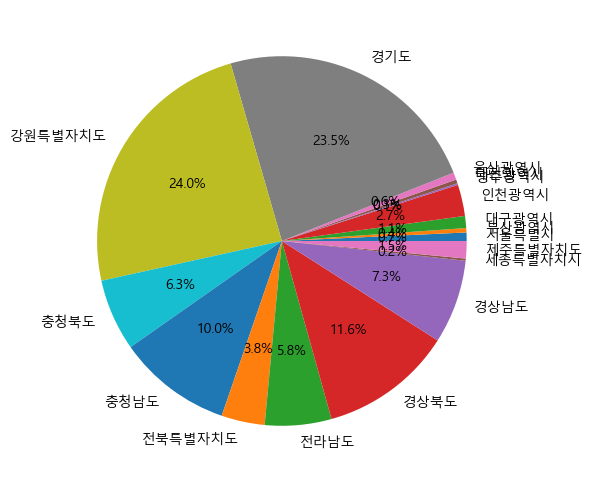

In [23]:
# 원형(파이) 차트 그리기
plt.figure(figsize=(10, 6))
plt.pie(ratio, labels=label, autopct='%.1f%%')
plt.show

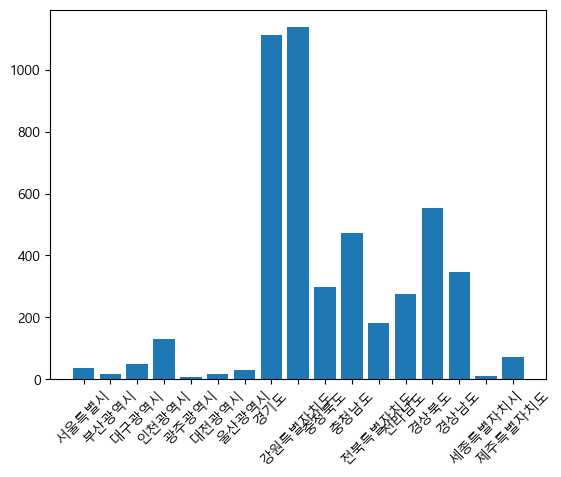

In [24]:
# 막대그래프 그리기
x = np.arange(len(data))   # X축 좌표 (0부터 시작하는 정수 배열)
plt.bar(x, ratio)
plt.xticks(x, label)
plt.xticks(rotation=45)
plt.show()